# Notebook 04 — Traditional ML Baseline (Random Forest)

**Purpose:** Train a Random Forest on hand-crafted features to establish a performance floor.

**Inputs:** Tiles from NB02, class weights from NB03  
**Outputs:**
- `models/rf_baseline_v1.joblib`
- `models/rf_baseline_metrics.json`
- `data/predictions/rf_baseline_test_predictions.npy`
- `figures/baselines/rf_confusion_matrix.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else '.')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

from skimage.feature import graycomatrix, graycoprops
from scipy.stats import skew, kurtosis

from src.utils import (
    PROCESSED_DIR, SPLITS_DIR, MODELS_DIR, PREDICTIONS_DIR, FIGURES_DIR,
    TERRAIN_CLASSES, NUM_CLASSES, get_logger,
)
from src.metrics import compute_all_metrics, print_metrics_table

log = get_logger('04_rf_baseline')

SAR_TILES_DIR = PROCESSED_DIR / 'sar_tiles'
LABEL_TILES_DIR = PROCESSED_DIR / 'label_tiles'
BASELINE_FIG_DIR = FIGURES_DIR / 'baselines'
BASELINE_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load split
with open(SPLITS_DIR / 'split_v1.json') as f:
    split_map = json.load(f)

train_ids = [k for k, v in split_map.items() if v == 'train']
val_ids = [k for k, v in split_map.items() if v == 'val']
test_ids = [k for k, v in split_map.items() if v == 'test']

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Train: 7497, Val: 1606, Test: 1608


## 1. Feature Extraction

Per-tile features:
- GLCM texture (contrast, dissimilarity, homogeneity, energy, correlation, ASM) at distances [1, 3, 5]
- Basic statistics (mean, std, median, skewness, kurtosis)

In [2]:
GLCM_DISTANCES = [1, 3, 5]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_PROPS = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']

def extract_features(sar_tile):
    """Extract hand-crafted feature vector from a SAR tile."""
    features = {}
    
    # Basic statistics
    valid = sar_tile[sar_tile > 0]
    if len(valid) == 0:
        valid = sar_tile.flatten()
    
    features['mean'] = float(valid.mean())
    features['std'] = float(valid.std())
    features['median'] = float(np.median(valid))
    features['skewness'] = float(skew(valid))
    features['kurtosis'] = float(kurtosis(valid))
    features['p10'] = float(np.percentile(valid, 10))
    features['p90'] = float(np.percentile(valid, 90))
    
    # GLCM texture features
    sar_q = (np.clip(sar_tile, 0, 1) * 63).astype(np.uint8)
    glcm = graycomatrix(sar_q, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                        levels=64, symmetric=True, normed=True)
    
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop)
        for d_idx, d in enumerate(GLCM_DISTANCES):
            features[f'{prop}_d{d}'] = float(vals[d_idx].mean())  # avg over angles
    
    return features


def get_majority_label(lbl_tile):
    """Get majority class label for a tile (ignoring nodata=255)."""
    valid = lbl_tile[lbl_tile != 255]
    if len(valid) == 0:
        return -1
    values, counts = np.unique(valid, return_counts=True)
    return int(values[np.argmax(counts)])

In [3]:
def extract_split_features(tile_ids, split_name):
    """Extract features and labels for a set of tile IDs."""
    records = []
    for tid in tqdm(tile_ids, desc=f'Features ({split_name})'):
        sar = np.load(SAR_TILES_DIR / f"{tid}.npy")
        lbl = np.load(LABEL_TILES_DIR / f"{tid}.npy")
        
        label = get_majority_label(lbl)
        if label < 0:
            continue
        
        feats = extract_features(sar)
        feats['tile_id'] = tid
        feats['label'] = label
        records.append(feats)
    
    return pd.DataFrame(records)

# Extract features for all splits
train_df = extract_split_features(train_ids, 'train')
val_df = extract_split_features(val_ids, 'val')
test_df = extract_split_features(test_ids, 'test')

print(f"Feature extraction complete:")
print(f"  Train: {len(train_df)} tiles, {train_df.shape[1]-2} features")
print(f"  Val:   {len(val_df)} tiles")
print(f"  Test:  {len(test_df)} tiles")

Features (train):   0%|          | 0/7497 [00:00<?, ?it/s]

Features (val):   0%|          | 0/1606 [00:00<?, ?it/s]

Features (test):   0%|          | 0/1608 [00:00<?, ?it/s]

Feature extraction complete:
  Train: 7497 tiles, 25 features
  Val:   1606 tiles
  Test:  1608 tiles


In [4]:
# Prepare X, y arrays
feature_cols = [c for c in train_df.columns if c not in ['tile_id', 'label']]

X_train = train_df[feature_cols].values
y_train = train_df['label'].values
X_val = val_df[feature_cols].values
y_val = val_df['label'].values
X_test = test_df[feature_cols].values
y_test = test_df['label'].values

print(f"Features: {feature_cols}")
print(f"X_train shape: {X_train.shape}")
print(f"Train label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Features: ['mean', 'std', 'median', 'skewness', 'kurtosis', 'p10', 'p90', 'contrast_d1', 'contrast_d3', 'contrast_d5', 'dissimilarity_d1', 'dissimilarity_d3', 'dissimilarity_d5', 'homogeneity_d1', 'homogeneity_d3', 'homogeneity_d5', 'energy_d1', 'energy_d3', 'energy_d5', 'correlation_d1', 'correlation_d3', 'correlation_d5', 'ASM_d1', 'ASM_d3', 'ASM_d5']
X_train shape: (7497, 25)
Train label distribution: {np.int64(0): np.int64(5362), np.int64(1): np.int64(769), np.int64(2): np.int64(634), np.int64(3): np.int64(308), np.int64(4): np.int64(399), np.int64(5): np.int64(25)}


## 2. Train Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

log.info("Training Random Forest...")
rf.fit(X_train, y_train)
log.info("Training complete.")

# Save model
model_path = MODELS_DIR / 'rf_baseline_v1.joblib'
joblib.dump(rf, model_path)
print(f"Model saved to {model_path}")

08:45:40 [04_rf_baseline] INFO: Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.1s


[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.5s


[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    1.4s finished


08:45:41 [04_rf_baseline] INFO: Training complete.


Model saved to /home/gabriel/titan-sar/models/rf_baseline_v1.joblib


## 3. Evaluate

In [6]:
# Predictions
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

# Save test predictions
np.save(PREDICTIONS_DIR / 'rf_baseline_test_predictions.npy', y_test_pred)

# Metrics
print("=" * 50)
print("VALIDATION SET")
print("=" * 50)
val_metrics = compute_all_metrics(y_val, y_val_pred)
print_metrics_table(val_metrics)

print("\n" + "=" * 50)
print("TEST SET")
print("=" * 50)
test_metrics = compute_all_metrics(y_test, y_test_pred)
print_metrics_table(test_metrics)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.1s


VALIDATION SET
Overall Accuracy: 0.7385
Mean IoU:         0.3536

Class              IoU     F1   Prec    Rec
-------------------------------------------
plains           0.726  0.841  0.812  0.872
dunes            0.228  0.371  0.491  0.298
hummocky         0.170  0.290  0.308  0.275
lakes_seas       0.593  0.744  0.696  0.800
labyrinth        0.406  0.577  0.597  0.558
craters          0.000  0.000  0.000  0.000

TEST SET
Overall Accuracy: 0.7357
Mean IoU:         0.3393

Class              IoU     F1   Prec    Rec
-------------------------------------------
plains           0.723  0.839  0.813  0.867
dunes            0.217  0.356  0.441  0.299
hummocky         0.176  0.300  0.343  0.267
lakes_seas       0.494  0.662  0.677  0.647
labyrinth        0.425  0.597  0.562  0.635
craters          0.000  0.000  0.000  0.000


[Parallel(n_jobs=16)]: Done 500 out of 500 | elapsed:    0.1s finished


In [7]:
# Save metrics
all_metrics = {
    'model': 'RandomForest_baseline_v1',
    'n_estimators': 500,
    'features': feature_cols,
    'validation': val_metrics,
    'test': test_metrics,
}

with open(MODELS_DIR / 'rf_baseline_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print(f"Metrics saved to {MODELS_DIR / 'rf_baseline_metrics.json'}")

Metrics saved to /home/gabriel/titan-sar/models/rf_baseline_metrics.json


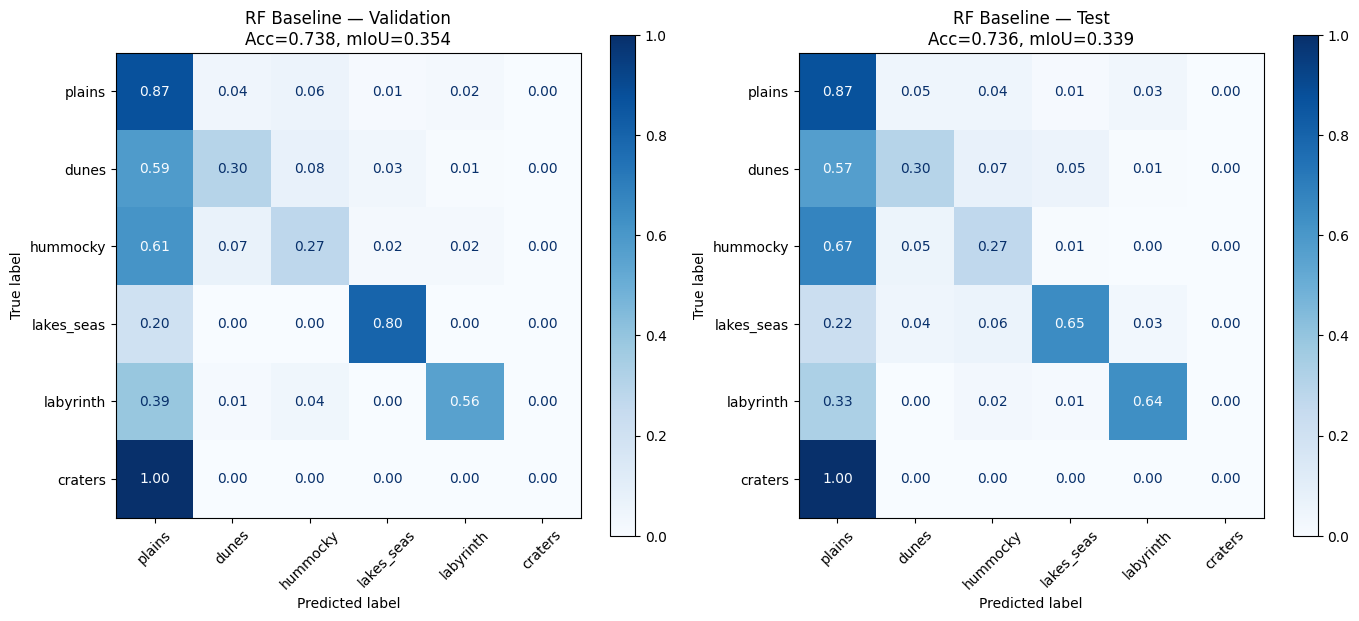

In [8]:
# Confusion matrix
class_names = [TERRAIN_CLASSES[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val, y_val_pred, 'Validation'),
    (y_test, y_test_pred, 'Test'),
]):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=class_names,
        normalize='true',
        ax=ax,
        cmap='Blues',
        values_format='.2f',
    )
    ax.set_title(f'RF Baseline — {title}\n'
                 f'Acc={compute_all_metrics(y_true, y_pred)["overall_accuracy"]:.3f}, '
                 f'mIoU={compute_all_metrics(y_true, y_pred)["mean_iou"]:.3f}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(BASELINE_FIG_DIR / 'rf_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Feature Importance

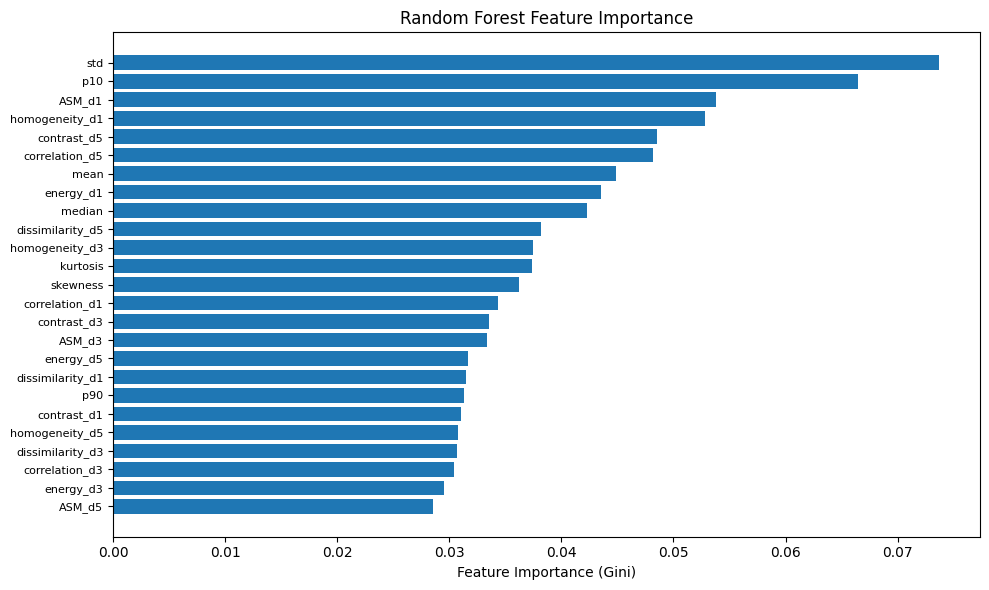


Top 10 features:
                        std: 0.0737
                        p10: 0.0665
                     ASM_d1: 0.0538
             homogeneity_d1: 0.0528
                contrast_d5: 0.0486
             correlation_d5: 0.0482
                       mean: 0.0448
                  energy_d1: 0.0435
                     median: 0.0423
           dissimilarity_d5: 0.0382


In [9]:
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(feature_cols)), importances[sorted_idx[::-1]], align='center')
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx[::-1]], fontsize=8)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig(BASELINE_FIG_DIR / 'rf_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for i in sorted_idx[:10]:
    print(f"  {feature_cols[i]:>25s}: {importances[i]:.4f}")

## 5. Sanity Checks

In [10]:
acc = test_metrics['overall_accuracy']
miou = test_metrics['mean_iou']

print(f"Test Accuracy: {acc:.3f}")
print(f"Test mIoU:     {miou:.3f}")
print()

if acc < 0.30:
    print("WARNING: Accuracy < 30%. Something may be wrong with the data pipeline.")
    print("  - Check SAR-label alignment in Notebook 02")
    print("  - Check class mapping")
    print("  - Check normalisation")
elif acc > 0.85:
    print("NOTE: Accuracy > 85%. RF baseline is already strong.")
    print("  - Deep learning may not add much — but that's also publishable.")
    print("  - Check for data leakage (spatial autocorrelation between splits).")
else:
    print(f"Baseline in expected range (30-85%). Deep learning should improve on this.")

print(f"\nReady for Notebook 05 (resolution sanity test) and Notebook 06 (deep learning).")

Test Accuracy: 0.736
Test mIoU:     0.339

Baseline in expected range (30-85%). Deep learning should improve on this.

Ready for Notebook 05 (resolution sanity test) and Notebook 06 (deep learning).
